# Convolutional Neural Networks (CNNs)

A **convolutional neural network**, or **CNN**, is a neural network designed to work especially well with grid-like data such as images. Instead of treating every pixel as an unrelated input, a CNN looks for small patterns in nearby pixels and reuses the same pattern detector across the image.

That simple idea lets a CNN learn visual clues in stages: early layers may respond to edges and color changes; deeper layers can combine those clues into textures, parts, and eventually whole objects. A CNN does not know what an edge or an object means in advance. It learns useful filters from examples during training.

### Learning goals

By the end of this lesson, you should be able to:

- Describe an image using height, width, and color channels.
- Explain what a convolutional filter and feature map do.
- Describe stride, padding, and pooling in simple terms.
- Explain why CNNs stack convolution and pooling stages.
- Trace how a CNN turns feature maps into class predictions.
- Distinguish training from using a trained model for prediction.

### One-image overview

A common image-classification pipeline is:

**image → convolution → activation → pooling → repeated feature stages → classifier → class scores**

The diagram below is a simplified map, not a rule that every CNN must follow. Some networks use different blocks, skip connections, or global average pooling instead of a large fully connected head.

### External architecture reference

![Typical CNN architecture: image input flows through convolution and pooling stages to fully connected classification layers.](https://upload.wikimedia.org/wikipedia/commons/6/63/Typical_cnn.png)

**Image source:** [Typical CNN architecture, Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Typical_cnn.png), by Aphex34, licensed under [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/). This is one example architecture; layer arrangements vary between CNNs.

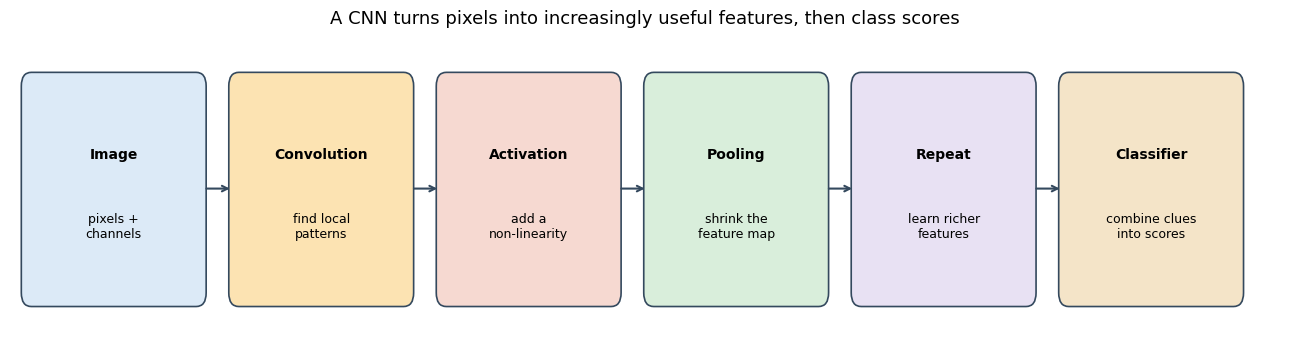

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

steps = [
    ("Image", "pixels +\nchannels", "#DCEAF7"),
    ("Convolution", "find local\npatterns", "#FCE3B2"),
    ("Activation", "add a\nnon-linearity", "#F6D9D1"),
    ("Pooling", "shrink the\nfeature map", "#D9EEDB"),
    ("Repeat", "learn richer\nfeatures", "#E8E1F3"),
    ("Classifier", "combine clues\ninto scores", "#F4E4C8"),
]

fig, ax = plt.subplots(figsize=(13, 3.6))
for index, (title, detail, color) in enumerate(steps):
    x = index * 1.65
    box = FancyBboxPatch((x, 0.35), 1.35, 1.25, boxstyle="round,pad=0.06,rounding_size=0.08",
                         facecolor=color, edgecolor="#34495E", linewidth=1.2)
    ax.add_patch(box)
    ax.text(x + 0.675, 1.18, title, ha="center", va="center", weight="bold", fontsize=10)
    ax.text(x + 0.675, 0.76, detail, ha="center", va="center", fontsize=9)
    if index < len(steps) - 1:
        ax.annotate("", xy=(x + 1.62, 0.98), xytext=(x + 1.39, 0.98),
                    arrowprops={"arrowstyle": "->", "color": "#34495E", "lw": 1.5})
ax.set_title("A CNN turns pixels into increasingly useful features, then class scores", fontsize=13)
ax.set_xlim(-0.15, 9.95)
ax.set_ylim(0.1, 1.9)
ax.axis("off")
fig.tight_layout()
plt.show()

## 1. What goes into a CNN?

An image is a grid of **pixels**. A grayscale image can be represented as a height-by-width array, such as `(28, 28)`. A color image commonly has three channels: **red, green, and blue**, giving a shape such as `(28, 28, 3)`. Pixel values are often converted from `0–255` to `0–1` before training; this is called **normalization** and helps keep numerical values manageable.

A CNN's first layers receive these image values and preserve their spatial arrangement. For a color image, a filter looks across all input channels in a small patch. The network learns the filter's values from training examples rather than receiving a hand-written rule for each object.

## 2. Convolution: a small pattern detector

A **filter** (or **kernel**) is a small grid of learned numbers. The convolution operation places this filter over a small image patch, multiplies matching values, and adds the results (often with a bias). It then moves the filter and repeats the calculation. Each position produces one number.

All those output numbers form a **feature map**. A high response means that the filter found a pattern it has learned to recognize at that location. One filter might respond to a particular edge; another may learn a different edge, color contrast, or texture. We do not usually name these patterns manually: training adjusts the filter values to help the model's predictions.

The important efficiency idea is **weight sharing**: the same filter is reused at every position. So the network can detect a learned pattern whether it appears near the top, middle, or bottom, without needing a separate set of weights for each location.

The illustration below uses a simple synthetic image and highlights one 3 × 3 patch. The real convolution calculation applies learned weights to that patch and then slides the filter to other locations.

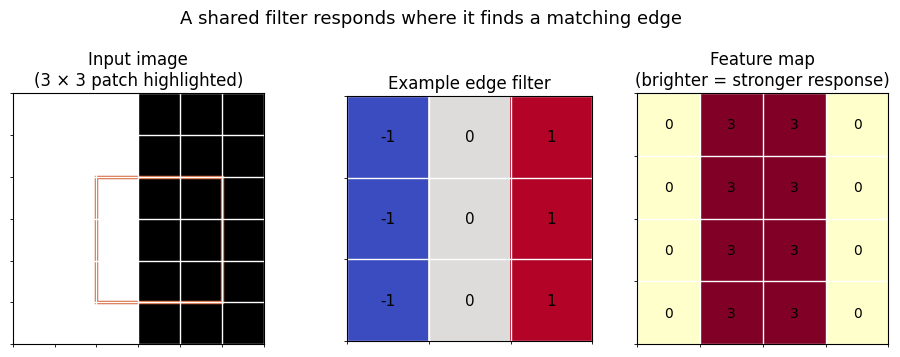

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

image = np.tile(np.array([0, 0, 0, 1, 1, 1]), (6, 1))
edge_filter = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
feature_map = np.zeros((4, 4), dtype=int)
for row in range(feature_map.shape[0]):
    for column in range(feature_map.shape[1]):
        patch = image[row:row + 3, column:column + 3]
        feature_map[row, column] = np.sum(patch * edge_filter)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.6), gridspec_kw={"width_ratios": [1.25, 0.8, 1]})
axes[0].imshow(image, cmap="gray_r", vmin=0, vmax=1)
axes[0].add_patch(Rectangle((1.5, 1.5), 3, 3, fill=False, edgecolor="#D76737", linewidth=2.5))
axes[0].set_title("Input image\n(3 × 3 patch highlighted)")
axes[1].imshow(edge_filter, cmap="coolwarm", vmin=-1, vmax=1)
for row in range(3):
    for column in range(3):
        axes[1].text(column, row, str(edge_filter[row, column]), ha="center", va="center", fontsize=11)
axes[1].set_title("Example edge filter")
axes[2].imshow(feature_map, cmap="YlOrRd", vmin=0, vmax=3)
for row in range(4):
    for column in range(4):
        axes[2].text(column, row, str(feature_map[row, column]), ha="center", va="center", fontsize=10)
axes[2].set_title("Feature map\n(brighter = stronger response)")
for ax in axes:
    ax.set_xticks(np.arange(-0.5, ax.images[0].get_array().shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, ax.images[0].get_array().shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("A shared filter responds where it finds a matching edge", fontsize=13)
fig.tight_layout()
plt.show()

### A few useful convolution settings

- **Filter size:** a 3 × 3 filter looks at a small neighborhood. Larger filters see a wider neighborhood at each step but use more weights.
- **Stride:** how many pixels the filter moves at a time. Stride 1 checks overlapping positions; stride 2 skips positions and gives a smaller output.
- **Padding:** extra border values added around the image, often zeros. Without padding, the output gets smaller as filters move across it. Padding can preserve more border information and, with suitable settings, keep the output size unchanged.
- **Activation:** after convolution, a function such as **ReLU** replaces negative values with zero: `ReLU(x) = max(0, x)`. This lets the network learn more complex, non-linear patterns.

For a square input of size $N$, filter size $F$, padding $P$, and stride $S$, the output size in one dimension is commonly:

$$
\left\lfloor\frac{N + 2P - F}{S}\right\rfloor + 1
$$

For example, a 6-pixel-wide input with a 3-pixel filter, no padding, and stride 1 gives `(6 - 3) / 1 + 1 = 4` output positions, matching the 4 × 4 feature map above.

## 3. Pooling: reduce the map while keeping strong clues

A **pooling layer** summarizes a small neighborhood of a feature map. A common choice is **2 × 2 max pooling with stride 2**: split the map into 2 × 2 regions and keep the largest value from each region. This halves the height and width when dimensions line up, making later computation smaller.

Pooling usually has no learned weights. It reduces spatial detail, but keeps strong responses that may indicate a feature was present nearby. **Average pooling** is another option; instead of taking the maximum, it averages the values in each region. Pooling is helpful, but too much downsampling can remove small details that matter.

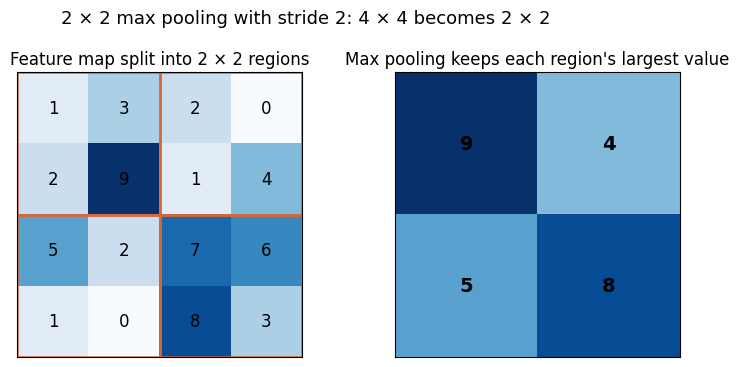

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

feature_map = np.array([
    [1, 3, 2, 0],
    [2, 9, 1, 4],
    [5, 2, 7, 6],
    [1, 0, 8, 3],
])
pooled = np.array([[feature_map[row:row + 2, column:column + 2].max()
                    for column in range(0, 4, 2)] for row in range(0, 4, 2)])

fig, (input_ax, output_ax) = plt.subplots(1, 2, figsize=(8, 3.7), gridspec_kw={"width_ratios": [1.25, 0.8]})
input_ax.imshow(feature_map, cmap="Blues", vmin=0, vmax=9)
for row in range(4):
    for column in range(4):
        input_ax.text(column, row, str(feature_map[row, column]), ha="center", va="center", fontsize=12)
for row in range(2):
    for column in range(2):
        input_ax.add_patch(Rectangle((column * 2 - 0.5, row * 2 - 0.5), 2, 2,
                                     fill=False, edgecolor="#D76737", linewidth=1.8))
input_ax.set_title("Feature map split into 2 × 2 regions")
input_ax.set_xticks([])
input_ax.set_yticks([])

output_ax.imshow(pooled, cmap="Blues", vmin=0, vmax=9)
for row in range(2):
    for column in range(2):
        output_ax.text(column, row, str(pooled[row, column]), ha="center", va="center", fontsize=14, weight="bold")
output_ax.set_title("Max pooling keeps each region's largest value")
output_ax.set_xticks([])
output_ax.set_yticks([])
fig.suptitle("2 × 2 max pooling with stride 2: 4 × 4 becomes 2 × 2", fontsize=13)
fig.tight_layout()
plt.show()

## 4. Why CNNs stack convolution and pooling

One convolution layer usually learns only a limited set of simple patterns. CNNs therefore stack several **convolution + activation** stages, often reducing the spatial size between stages:

- Early filters can respond to simple local changes such as edges, color boundaries, or small textures.
- Later filters receive earlier feature maps and can combine simple responses into more complex patterns.
- Pooling or a strided convolution can reduce height and width, so deeper layers process a smaller grid while keeping multiple feature channels.

Each filter produces one feature map. If a convolution uses 16 filters, its output usually has 16 feature channels. Pooling typically reduces height and width but keeps the number of channels the same.

### A small shape example

Suppose an input image has shape `32 × 32 × 3` (height, width, and RGB channels):

1. A convolution with 16 filters of size 3 × 3, stride 1, and padding 1 can produce `32 × 32 × 16`.
2. A 2 × 2 pooling layer with stride 2 reduces that to `16 × 16 × 16`.
3. A second convolution with 32 filters, again preserving the spatial size, gives `16 × 16 × 32`.
4. Another 2 × 2 pooling layer gives `8 × 8 × 32`.

The exact design varies. Too little reduction can make later computation large; too much reduction can erase small but important details.

## 5. Fully connected layer: turn learned clues into a decision

After feature extraction, the model needs to map its features to the task's output. A traditional CNN **flattens** the final feature maps into a vector and sends it to one or more **fully connected (dense) layers**. These layers combine the detected clues and produce one score for each class.

Some modern CNNs instead use **global average pooling**: average each feature map into one number, then classify those numbers. This can use fewer parameters than flattening a large feature grid.

The final raw scores are called **logits**. For a task with mutually exclusive classes, **softmax** can convert logits to probabilities that sum to 1. For example, the model might output `cat: 0.82`, `dog: 0.13`, `bird: 0.05`; the largest probability is the predicted class. A model's confidence is not automatically a guarantee that the prediction is correct.

## 6. How does a CNN learn?

During **training**, the network receives an image and its correct label. Its current prediction is compared with that label using a **loss function**, often cross-entropy for classification. The loss is a number that measures how wrong the prediction was.

**Backpropagation** calculates how each learnable weight contributed to the loss. An **optimizer**, such as stochastic gradient descent or Adam, uses those calculations to adjust the filter and classifier weights. Repeating this over many labeled examples helps the model produce lower-loss predictions. The filters are learned through this process; pooling itself usually has no weights to learn.

During **inference** (prediction), the trained model receives a new image and computes its output. It does not update its weights. To understand whether it generalizes, evaluate it on examples that were not used to train it.

## 7. Strengths, trade-offs, and recap

CNNs are useful because they keep the image's local structure, reuse filters across positions, and can learn features in stages. This often gives them a more efficient starting point for image tasks than connecting every raw pixel directly to every hidden neuron.

They are not magic or always the right choice. CNNs still need representative data and computation; pooling can discard details; and a high score on training images does not prove the model works well on new images. The right architecture depends on the task, data, and available resources. For small datasets, a pretrained CNN may be a practical starting point.

### Quick self-check

1. What does one filter produce when it moves across an image?
2. What does weight sharing mean?
3. How does 2 × 2 max pooling with stride 2 change a 32 × 32 feature map?
4. What is the difference between logits and softmax probabilities?
5. Do pooling layers usually learn weights? What part of a CNN learns filters?
6. What is the difference between training and inference?

<details>
<summary>Show suggested answers</summary>

1. A feature map: a grid of responses, one for each filter position.
2. The same filter weights are reused at different image locations.
3. It reduces the spatial dimensions to 16 × 16 (assuming dimensions line up), while retaining the feature channels.
4. Logits are raw class scores; softmax turns them into non-negative probabilities that sum to 1 for a single-label classification task.
5. Pooling usually has no learned weights. Convolution filters are learned during training through backpropagation and an optimizer.
6. Training adjusts the model's weights using examples and labels; inference uses the learned weights to make predictions without updating them.

</details>

### The big picture

A CNN first looks for local visual patterns with shared filters, reduces or summarizes feature maps, builds richer features by stacking layers, and finally classifies the resulting representation. Its structure is a useful fit for images because it takes advantage of nearby pixels and repeated patterns.